# 09 · Activity-coefficient models

Ethanol and water do not obey Raoult's law: the mixture boils at a lower temperature than either predicts,
and no distillation column can take ethanol beyond 89 mol % - the azeotrope. Activity coefficients describe
such non-ideal liquids; this notebook fits the classical models (Margules, van Laar, Wilson, NRTL) to data,
checks the data for thermodynamic consistency, and locates the azeotrope that shapes the bioethanol industry.

**What you will learn**
- extract activity coefficients from VLE data
- fit Margules, van Laar, Wilson and NRTL models
- test data for thermodynamic consistency
- locate azeotropes and understand their consequences for distillation

**Before you start:** notebooks 07-08  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, datasets, mixtures, vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## The data, and Raoult's law's failure

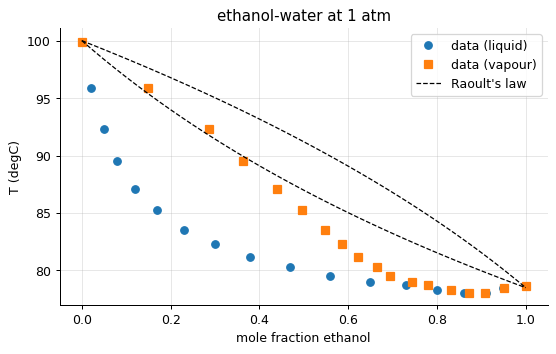

In [2]:
d = pd.read_csv(datasets.path("ethanol_water_vle_1atm.csv"), comment="#")
comps, p = ["ethanol", "water"], 101325.0
raoult = vle.Txy(comps, p, n=41)
plt.plot(d.x_ethanol, d.T_C, "o", label="data (liquid)"); plt.plot(d.y_ethanol, d.T_C, "s", label="data (vapour)")
plt.plot(raoult["x1"], raoult["T"] - 273.15, "k--", lw=1, label="Raoult's law"); plt.plot(raoult["y1"], raoult["T"] - 273.15, "k--", lw=1)
plt.xlabel("mole fraction ethanol"); plt.ylabel("T (degC)"); plt.title("ethanol-water at 1 atm"); plt.legend(); plt.show()

Raoult's law predicts a smooth lens between 100 and 78.3 degC; the real mixture boils *below* both pure
components near x = 0.9 - a **minimum-boiling azeotrope**, where liquid and vapour have the same composition.
Positive deviations from Raoult's law (activity coefficients above 1) cause it: water and ethanol molecules
prefer their own kind.

## Activity coefficients from the data
Modified Raoult's law, $y_i p = x_i\gamma_i p_i^{sat}$, turns each data point into activity coefficients:

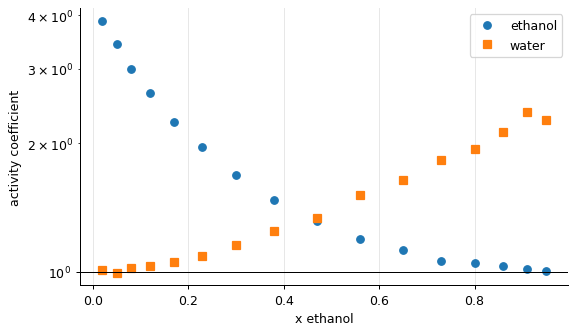

ethanol at infinite dilution in water: gamma about 3.9; water in ethanol: about 2.3


In [3]:
inner = d[(d.x_ethanol > 0) & (d.x_ethanol < 1)]
T = inner.T_C.to_numpy() + 273.15
g1 = inner.y_ethanol * p / (inner.x_ethanol * vapor.antoine_psat("ethanol", T))
g2 = (1 - inner.y_ethanol) * p / ((1 - inner.x_ethanol) * vapor.antoine_psat("water", T))
plt.semilogy(inner.x_ethanol, g1, "o", label="ethanol"); plt.semilogy(inner.x_ethanol, g2, "s", label="water")
plt.axhline(1, color="k", lw=0.8); plt.xlabel("x ethanol"); plt.ylabel("activity coefficient"); plt.legend(); plt.show()
print(f"ethanol at infinite dilution in water: gamma about {g1.iloc[0]:.1f}; water in ethanol: about {g2.iloc[-1]:.1f}")

Both coefficients exceed 1 and grow towards infinite dilution: a molecule surrounded by the other species is
"uncomfortable" and escapes more readily than Raoult's law expects. The excess Gibbs energy
$G^E/RT = \sum x_i\ln\gamma_i$ summarises the non-ideality in one curve.

## Fitting the models

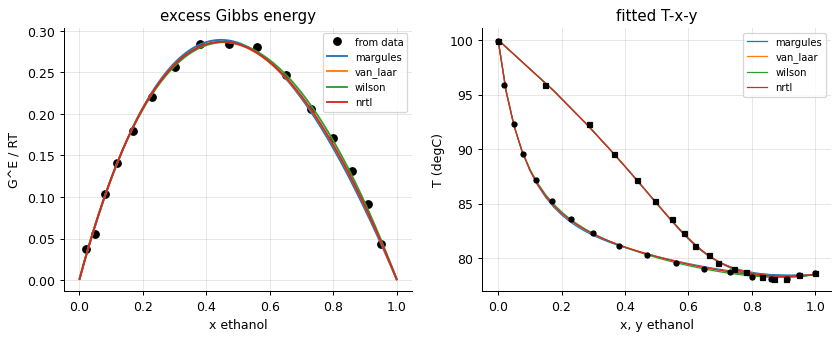

margules : rms error in p 1.08 %; azeotrope at x = 0.924, 78.42 degC
van_laar : rms error in p 0.73 %; azeotrope at x = 0.907, 78.34 degC
wilson   : rms error in p 0.52 %; azeotrope at x = 0.890, 78.23 degC
nrtl     : rms error in p 0.72 %; azeotrope at x = 0.905, 78.33 degC


In [4]:
fits = {m: activity.fit(m, comps, inner.x_ethanol, T, p, y1=inner.y_ethanol) for m in ("margules", "van_laar", "wilson", "nrtl")}
xx = np.linspace(0.001, 0.999, 200)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(inner.x_ethanol, inner.x_ethanol * np.log(g1) + (1 - inner.x_ethanol) * np.log(g2), "ko", label="from data")
for m, f in fits.items():
    a1.plot(xx, [activity.excess_gibbs(f["gamma"], [x, 1 - x], 351.0) for x in xx], label=m)
    txy = vle.Txy(comps, p, f["gamma"], n=41)
    a2.plot(txy["x1"], txy["T"] - 273.15, lw=1, label=m); a2.plot(txy["y1"], txy["T"] - 273.15, lw=1, color=a2.lines[-1].get_color())
a1.set(xlabel="x ethanol", ylabel="G^E / RT", title="excess Gibbs energy"); a1.legend(fontsize=8)
a2.plot(d.x_ethanol, d.T_C, "ko", ms=4); a2.plot(d.y_ethanol, d.T_C, "ks", ms=4); a2.set(xlabel="x, y ethanol", ylabel="T (degC)", title="fitted T-x-y"); a2.legend(fontsize=8)
plt.show()
for m, f in fits.items():
    az = activity.azeotrope(comps, f["gamma"], p=p)
    print(f"{m:<9}: rms error in p {100*f['rms_p']:.2f} %; azeotrope at x = {az['x1']:.3f}, {az['T']-273.15:.2f} degC")

All four models fit the pressures within about 1 %, but they disagree on the azeotrope: Wilson lands on
x = 0.890 (experimentally 0.894 at 78.15 degC), van Laar and NRTL about 0.905, and the symmetric-looking
Margules model 0.924. The azeotrope sits where the two curves cross at a shallow angle, so it magnifies small
differences in the models' shapes. Wilson and NRTL, which describe asymmetric systems best and carry a
temperature dependence, are the industrial favourites; Margules and van Laar are simple but extrapolate poorly.

## Are the data consistent? The area test
The Gibbs-Duhem equation links the two activity coefficients: for a consistent isobaric data set,
$\int_0^1\ln(\gamma_1/\gamma_2)\,dx_1 \approx 0$ (the areas above and below zero cancel):

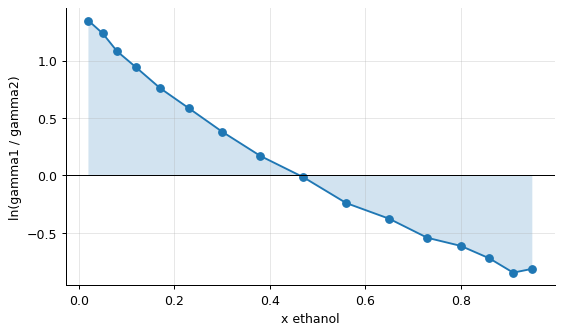

area above zero 0.260, below 0.230: index |A+ - A-|/(A+ + A-) = 0.060 (pass if < 0.10)
the fitted Wilson model itself: index 0.0000


In [5]:
ratio = np.log(g1 / g2)
x_d = inner.x_ethanol.to_numpy()
plt.plot(x_d, ratio, "o-"); plt.axhline(0, color="k", lw=0.8); plt.fill_between(x_d, ratio, 0, alpha=0.2)
plt.xlabel("x ethanol"); plt.ylabel("ln(gamma1 / gamma2)"); plt.show()
pos = np.trapezoid(np.maximum(ratio, 0), x_d); neg = -np.trapezoid(np.minimum(ratio, 0), x_d)
print(f"area above zero {pos:.3f}, below {neg:.3f}: index |A+ - A-|/(A+ + A-) = {abs(pos - neg)/(pos + neg):.3f} (pass if < 0.10)")
print(f"the fitted Wilson model itself: index {activity.redlich_kister_area(fits['wilson']['gamma'], 351.0)['index']:.4f}")

The data pass. Real published data sets do not always: the area test is the first filter applied before any
parameters are fitted, because inconsistent data cannot be described by any model that obeys the
Gibbs-Duhem equation.

## The azeotrope and bioethanol
Fermentation gives about 10 % ethanol; distillation concentrates it - but only to the azeotrope:

In [6]:
az = activity.azeotrope(comps, fits["wilson"]["gamma"], p=p)
print(f"azeotrope at 1 atm: {az['x1']:.3f} mole fraction = {az['x1']*46.07/(az['x1']*46.07 + (1-az['x1'])*18.02):.1%} by mass, {az['T']-273.15:.1f} degC")
for p_low in (0.3e5, 0.1e5):
    az_low = activity.azeotrope(comps, fits["wilson"]["gamma"], p=p_low)
    print(f"at {p_low/1e5:.1f} bar: " + (f"azeotrope at x = {az_low['x1']:.3f}, {az_low['T']-273.15:.1f} degC" if az_low else "no azeotrope"))

azeotrope at 1 atm: 0.890 mole fraction = 95.4% by mass, 78.2 degC
at 0.3 bar: azeotrope at x = 0.918, 50.2 degC


at 0.1 bar: azeotrope at x = 0.942, 29.0 degC


Ordinary distillation stops at about 95-96 % by mass. Fuel-grade ethanol needs more: pressure-swing
distillation (the azeotrope moves, or vanishes, at low pressure), an entrainer that breaks it (azeotropic
distillation), or molecular sieves. The whole design question turns on the activity coefficients of this
notebook.

## Inside the algorithm: the two-parameter Margules equations
$\ln\gamma_1 = x_2^2[A_{12} + 2(A_{21} - A_{12})x_1]$, $\ln\gamma_2 = x_1^2[A_{21} + 2(A_{12} - A_{21})x_2]$:

In [7]:
A12, A21 = fits["margules"]["params"]["A12"], fits["margules"]["params"]["A21"]
x1_ = 0.3
by_hand = np.exp([0.7**2 * (A12 + 2 * (A21 - A12) * x1_), x1_**2 * (A21 + 2 * (A12 - A21) * 0.7)])
print("by hand:", by_hand.round(5), " library:", fits["margules"]["gamma"]([x1_, 0.7]).round(5))

by hand: [1.70741 1.15531]  library: [1.70741 1.15531]


## Exercises
1. Fit the Wilson model to only the data with x_ethanol < 0.5. How well does it predict the azeotrope? What does this say about extrapolating activity models beyond the data range?
2. Using the fitted NRTL model, compute the minimum reflux-related quantity that matters most for a designer: the relative volatility $\alpha = y_1 x_2/(x_1 y_2)$ as a function of x_ethanol at 1 atm. Where does it fall below 1.1?
3. **Implement it yourself:** write a bubble-temperature solver with modified Raoult's law (activity coefficients from `activity.margules`) and reproduce the fitted T-x-y curve.